<a href="https://colab.research.google.com/github/roshnimishraa/Roshni-ML-with-Gen-AI/blob/main/Roshni_Mishra_02002212025_Week_2_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Part A: Dataset Understanding

### Q1. Load the dataset and display the first five records.

In [ ]:
# load dataset
df = pd.read_csv("/content/Dataset 2.csv")
df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


### Q2. Determine the number of rows and columns in the dataset.

In [ ]:
# Shape of Dataset
df.shape

(750, 10)

### Q3. Display all column names.

In [ ]:
df.columns

Index(['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek',
       'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend',
       'SubscriptionRenewed'],
      dtype='object')

### Q4. Identify numerical and categorical features.

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Features:")
print(num_cols)

print("\nCategorical Features:")
print(cat_cols)

Numerical Features:
Index(['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks',
       'MonthlySpend'],
      dtype='object')

Categorical Features:
Index(['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed'], dtype='object')


### Q5. Check whether the dataset contains missing values.

In [ ]:
df.isnull().sum()

,0
UserID,0
Age,0
Gender,0
SubscriptionType,0
WatchHoursPerWeek,0
DevicesUsed,0
FavoriteGenre,0
AdClicks,0
MonthlySpend,0
SubscriptionRenewed,0


## Part B: Exploratory Data Analysis

### Q6. Calculate the average age of users.

In [ ]:
df["Age"].mean()

np.float64(41.824)

### Q7. Determine the average watch hours per week.

In [ ]:
df["WatchHoursPerWeek"].mean()

np.float64(14.236)

### Q8. Find the average monthly spending of users.

In [ ]:
df["MonthlySpend"].mean()

np.float64(689.9053333333334)

### Q9. Count the number of users in each subscription category.

In [ ]:
df["SubscriptionType"].value_counts()

,count
SubscriptionType,
Basic,342
Premium,279
VIP,129


### Q10. Determine the percentage of users who renewed their subscriptions.

In [ ]:
(df["SubscriptionRenewed"]=="Yes").mean()*100

np.float64(46.266666666666666)

## Part C: Data Preparation

### Q11. Convert categorical features into numerical form.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["SubscriptionType"] = le.fit_transform(df["SubscriptionType"])
df["FavoriteGenre"] = le.fit_transform(df["FavoriteGenre"])
df["SubscriptionRenewed"] = le.fit_transform(df["SubscriptionRenewed"])

df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,0,0,23,5,1,13,353,0
1,1002,55,1,0,9,4,2,14,317,1
2,1003,49,1,0,8,3,1,16,309,0
3,1004,39,0,1,19,5,2,45,833,1
4,1005,38,0,1,23,5,5,24,804,1


### Q12. Define the feature set (X) and target variable (y) for subscription renewal prediction

In [ ]:
X = df.drop("SubscriptionRenewed", axis=1)
y = df["SubscriptionRenewed"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (750, 9)
Target Shape: (750,)


### Q13. Split the dataset into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (600, 9)
X_test: (150, 9)
y_train: (600,)
y_test: (150,)


## Part D: Decision Tree Classification

### Q14. Train a Decision Tree model to predict whether a user will renew their subscription.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


### Q15. Evaluate the model using accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.5666666666666667


### Q16. Generate and interpret the confusion matrix.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, dt_pred)

print(cm)

[[50 32]
 [33 35]]


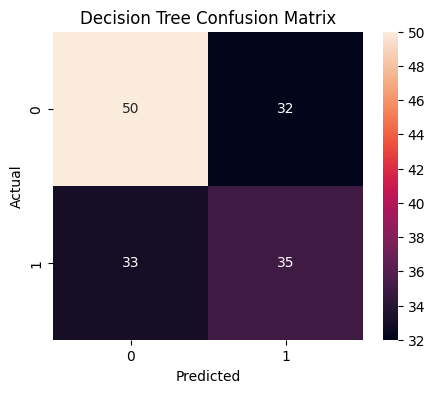

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Part E: K-Nearest Neighbors (KNN)

### Q17. Train a KNN classifier with K = 5.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

print("KNN Model Trained Successfully")

KNN Model Trained Successfully


### Q18. Compare the accuracy of KNN with the Decision Tree model.

In [ ]:
knn_pred = knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("Decision Tree Accuracy =", dt_accuracy)
print("KNN Accuracy =", knn_accuracy)

Decision Tree Accuracy = 0.5666666666666667
KNN Accuracy = 0.5666666666666667


In [ ]:
if dt_accuracy > knn_accuracy:
    print("Decision Tree performed better.")
elif knn_accuracy > dt_accuracy:
    print("KNN performed better.")
else:
    print("Both models performed equally.")

Both models performed equally.


## Part F: Linear Regression

### Q19. Train a Linear Regression model to predict monthly spending

In [ ]:
from sklearn.linear_model import LinearRegression

X_reg = df.drop("MonthlySpend", axis=1)
y_reg = df["MonthlySpend"]

from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

lr = LinearRegression()

lr.fit(X_train_r, y_train_r)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


### Q20. Predict the monthly spending for a new user and interpret the result.

In [ ]:
prediction = lr.predict([X_test_r.iloc[0]])

print("Predicted Monthly Spending = ₹", prediction[0])

Predicted Monthly Spending = ₹ 838.5871865891327


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Business Reflection Questions

###Q1. Which factors appear to influence subscription renewal the most?

**Ans.** WatchHoursPerWeek, SubscriptionType, MonthlySpend, DevicesUsed, and AdClicks appear to have the strongest influence on subscription renewal because they reflect user engagement and spending behavior.

---

###Q2. Why is subscription renewal a classification problem?

**Ans.** Subscription renewal is a classification problem because the target variable has two categories: Yes and No.

---

###Q3. Why is monthly spending a regression problem?

**Ans.** Monthly spending is a regression problem because the target variable is a continuous numerical value rather than a category.

---

###Q4. Which algorithm performed better for renewal prediction?

**Ans.** The algorithm with the higher accuracy score between Decision Tree and KNN performed better for subscription renewal prediction.

---

###Q5. How could the platform use these predictions to improve customer retention?.

**Ans.** Netflix can identify users who are likely to cancel their subscriptions and provide personalized recommendations, discounts, loyalty rewards, or targeted marketing campaigns to encourage renewal and improve customer retention.